In [ ]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch
import torch.nn as nn
import torchvision.models as models
import pandas as pd
import numpy as np
import os

class MelanomaMultiModalDataset(Dataset):
    def __init__(self, dataframe, img_dir, abcd_means, abcd_stds, transform=None):

        self.dataframe = dataframe.reset_index(drop=True) 
        self.img_dir = img_dir
        self.transform = transform
        
        self.abcd_means = abcd_means
        self.abcd_stds = abcd_stds

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_id = self.dataframe.loc[idx, 'image']
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        raw_abcd = self.dataframe.loc[idx, ['A', 'B', 'C', 'D']].values.astype(np.float32)
        
        norm_abcd = (raw_abcd - self.abcd_means) / self.abcd_stds
        abcd_tensor = torch.tensor(norm_abcd, dtype=torch.float32)

        label = self.dataframe.loc[idx, 'label']
        label_tensor = torch.tensor(label, dtype=torch.long)
        return (image, abcd_tensor), label_tensor

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

df_test=pd.read_csv("TestClassAnnotations.csv")
test_folder="SegDataset/test/testInput"
test_abcd_values = df_test[['A', 'B', 'C', 'D']].values

abcd_means = test_abcd_values.mean(axis=0)
abcd_stds = test_abcd_values.std(axis=0)

abcd_stds = np.where(abcd_stds < 1e-6, 1e-6, abcd_stds)
test_dataset = MelanomaMultiModalDataset(
    df_test, test_folder, abcd_means, abcd_stds, transform=None)

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = MelanomaMultiModalDataset(
    dataframe=df_test, 
    img_dir=test_folder, 
    abcd_means=abcd_means,
    abcd_stds=abcd_stds,
    transform=val_test_transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
class MelanomaLateFusionModel(nn.Module):
    def __init__(self, num_classes=3, num_tabular_features=4):
        super(MelanomaLateFusionModel, self).__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.image_model = models.efficientnet_b0(weights=weights)
        self.image_model.classifier = nn.Identity()
        self.tabular_model = nn.Sequential(
            nn.Linear(num_tabular_features, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU()
        )
        fusion_size = 1280 + 16
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(fusion_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, tabular):
        img_features = self.image_model(image)
        tab_features = self.tabular_model(tabular)
        
        fused_features = torch.cat((img_features, tab_features), dim=1)
        output = self.classifier(fused_features)
        
        return output
#Sanity check 
if __name__ == "__main__":
    model = MelanomaLateFusionModel(num_classes=3)
    dummy_images = torch.randn(8, 3, 224, 224)
    dummy_abcd = torch.randn(8, 4)
    
    predictions = model(dummy_images, dummy_abcd)
    
    print(f"Kształt wejścia obrazów: {dummy_images.shape}")
    print(f"Kształt wejścia ABCD: {dummy_abcd.shape}")
    print(f"Kształt wyjścia modelu: {predictions.shape}")
    print("Jeśli tu dotarłeś bez błędu, Twoja architektura działa perfekcyjnie!")

Kształt wejścia obrazów: torch.Size([8, 3, 224, 224])
Kształt wejścia ABCD: torch.Size([8, 4])
Kształt wyjścia modelu: torch.Size([8, 3])
Jeśli tu dotarłeś bez błędu, Twoja architektura działa perfekcyjnie!


Rozpoczynam testowanie na urządzeniu: cuda
Pomyślnie załadowano wagi najlepszego modelu!
Trwa ocenianie na zbiorze testowym...

--- WYNIKI OGÓLNE ---
Dokładność (Accuracy) na zbiorze testowym: 77.31%

--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

         MEL       0.62      0.38      0.47        53
          NV       0.86      0.87      0.86       187
         BKL       0.47      0.90      0.62        20

    accuracy                           0.77       260
   macro avg       0.65      0.72      0.65       260
weighted avg       0.78      0.77      0.77       260



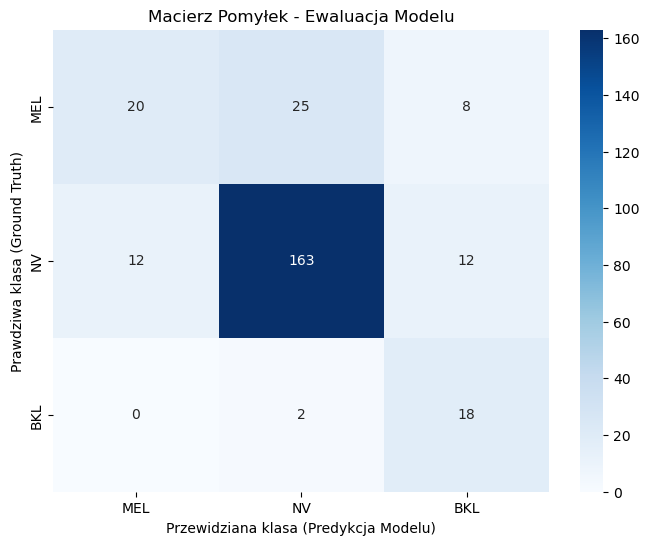

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Rozpoczynam testowanie na urządzeniu: {device}")

model = MelanomaLateFusionModel(num_classes=3).to(device)

try:
    model.load_state_dict(torch.load("CNet-best1.pth"))
    print("Pomyślnie załadowano wagi najlepszego modelu!")
except FileNotFoundError:
    print("BŁĄD: Nie znaleziono pliku best_melanoma_model.pth. Upewnij się, że trening się zakończył.")
    exit()

model.eval()

all_preds = []
all_labels = []

print("Trwa ocenianie na zbiorze testowym...")

with torch.no_grad():
    for (images, tabular), labels in test_loader:
        images = images.to(device)
        tabular = tabular.to(device)
        labels = labels.to(device)
        
        outputs = model(images, tabular)
        
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['MEL', 'NV', 'BKL']

correct = np.sum(np.array(all_preds) == np.array(all_labels))
accuracy = correct / len(all_labels)
print(f"\n--- WYNIKI OGÓLNE ---")
print(f"Dokładność (Accuracy) na zbiorze testowym: {accuracy * 100:.2f}%\n")

print("--- RAPORT KLASYFIKACJI ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Przewidziana klasa (Predykcja Modelu)')
plt.ylabel('Prawdziwa klasa (Ground Truth)')
plt.title('Macierz Pomyłek - Ewaluacja Modelu')
plt.show()